In [1]:
from __future__ import annotations

import cirq
import numpy as np
from cirq.ops import GlobalPhaseGate

# Needed for text/SVG diagrams: top-level ``cirq.GlobalPhaseGate`` can be missing in some kernels.
setattr(cirq, "GlobalPhaseGate", GlobalPhaseGate)

import sympy
from IPython.display import display

from cirq.contrib.svg import SVGCircuit

# Shared sampling/CDR settings used across later notebook cells.
GLOBAL_NUM_SHOTS = 8192
CDR_NUM_TRAINING_CIRCUITS = 30
CDR_T_MAX_GRADIENT = 2
CDR_T_MAX_VQE = CDR_T_MAX_GRADIENT
CDR_BASE_SEED = 42
GLOBAL_RANDOM_SEED = 1234
GLOBAL_SAMPLING_SEED = 1234
GLOBAL_MEASUREMENT_SCHEME = "ogm"
GLOBAL_APPLY_READOUT_NOISE = True
GLOBAL_READOUT_P0_SUCCESS = np.array([0.97, 0.96, 0.93, 0.96, 0.92, 0.93, 0.94, 0.92])
GLOBAL_READOUT_P1_SUCCESS = np.array([0.85, 0.90, 0.88, 0.90, 0.86, 0.89, 0.87, 0.85])


--- Cirq FSim Ansatz (random viz params) ---
param_map: {'ph_0_3': 6.136785623643497, 'ph_0_4': 2.388840256127606, 'ph_0_5': 5.800927170894575, 'ph_0_6': 1.6442619926196334, 'th_0_0': 2.004945948992312, 'th_0_1': 0.7419890998827317, 'th_0_2': 1.5190624215371704}
                                                   ┌──────────────────────────────────────────────────────────────┐
(0, 0): ───────FSim(0.638π, 0)──────────────────────FSim(0, -0.0466π)─────────────────────────────────────────────────
               │                                    │
(0, 1): ───X───FSim(0.638π, 0)───FSim(0.484π, 0)────┼────────────────FSim(0, 0.76π)───────────────────────────────────
                                 │                  │                │
(0, 2): ───────FSim(0.236π, 0)───FSim(0.484π, 0)────┼────────────────┼─────────────FSim(0, -0.154π)───────────────────
               │                                    │                │             │
(0, 3): ───X───FSim(0.236π, 0)──────────────────────┼─

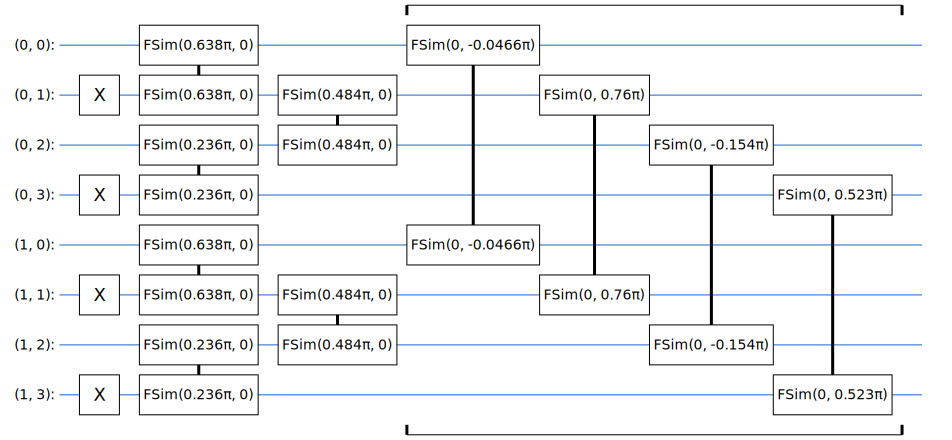

In [2]:
# construct the circuit

def prepare_ansatz_cirq(num_spatial_orbitals, num_layers=1):
    # Map Alpha to Row 0, Beta to Row 1
    qubits = [cirq.GridQubit(0, i) for i in range(num_spatial_orbitals)] + \
             [cirq.GridQubit(1, i) for i in range(num_spatial_orbitals)]

    circuit = cirq.Circuit()
    p_idx = 0

    # --- STEP 1: INITIAL STATE ---
    initial_gates = [cirq.X(qubits[i]) for i in range(1, len(qubits), 2)]
    circuit.append(initial_gates)

    for layer in range(num_layers):
        # --- STEP 2: GIVENS ROTATION G (Even-Odd) ---
        even_odd_moments = []
        for i in range(0, num_spatial_orbitals - 1, 2):
            theta = sympy.Symbol(f"th_{layer}_{p_idx}")
            even_odd_moments.append(cirq.FSimGate(theta, 0).on(qubits[i], qubits[i + 1]))
            even_odd_moments.append(
                cirq.FSimGate(theta, 0).on(
                    qubits[i + num_spatial_orbitals], qubits[i + 1 + num_spatial_orbitals]
                )
            )
            p_idx += 1

        circuit.append(even_odd_moments, strategy=cirq.InsertStrategy.NEW_THEN_INLINE)

        # --- STEP 3: GIVENS ROTATION G' (Odd-Even) ---
        odd_even_moments = []
        for i in range(1, num_spatial_orbitals - 1, 2):
            theta = sympy.Symbol(f"th_{layer}_{p_idx}")
            odd_even_moments.append(cirq.FSimGate(theta, 0).on(qubits[i], qubits[i + 1]))
            odd_even_moments.append(
                cirq.FSimGate(theta, 0).on(
                    qubits[i + num_spatial_orbitals], qubits[i + 1 + num_spatial_orbitals]
                )
            )
            p_idx += 1

        circuit.append(odd_even_moments, strategy=cirq.InsertStrategy.NEW_THEN_INLINE)

        # --- STEP 4: ON-SITE POTENTIAL (Double Occupancy) ---
        onsite_moments = []
        for i in range(num_spatial_orbitals):
            phi = sympy.Symbol(f"ph_{layer}_{p_idx}")
            q_alpha = qubits[i]
            q_beta = qubits[i + num_spatial_orbitals]
            onsite_moments.append(cirq.FSimGate(0, phi).on(q_alpha, q_beta))
            p_idx += 1

        circuit.append(onsite_moments, strategy=cirq.InsertStrategy.NEW_THEN_INLINE)

    return circuit, qubits

# --- Test Case ---
num_spatial = 4
num_layers = 1
ansatz_circuit, ansatz_qubits = prepare_ansatz_cirq(
    num_spatial_orbitals=num_spatial, num_layers=num_layers
)

# Diagram with a random angle for each symbolic parameter.
rng_viz = np.random.default_rng(GLOBAL_RANDOM_SEED)
param_map = {
    name: float(rng_viz.uniform(0, 2 * np.pi))
    for name in sorted(cirq.parameter_names(ansatz_circuit))
}

resolver_viz = cirq.ParamResolver(param_map)
circuit_draw = cirq.resolve_parameters(ansatz_circuit, resolver_viz)

print("--- Cirq FSim Ansatz (random viz params) ---")
print("param_map:", param_map)
print(circuit_draw)
print(f"\nCircuit Depth: {len(ansatz_circuit)} moments")
display(SVGCircuit(circuit_draw))

In [3]:
import sys
from pathlib import Path

# Repo root resolution for local file loading.
_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

from decompose_fsim_gate import (
    decompose_fsim_phi_only,
    decompose_fsim_theta_only,
    is_cz_plus_single_qubit,
)


def load_pauli_sum_from_numbered_file(path: Path, qubits: list[cirq.Qid]) -> cirq.PauliSum:
    """Read ``coeff q0 q1 ...`` lines (0=I, 1=X, 2=Y, 3=Z) into a ``PauliSum``."""
    idx_to_pauli = {1: cirq.X, 2: cirq.Y, 3: cirq.Z}
    out = cirq.PauliSum()

    with path.open("r", encoding="utf-8") as f:
        for lineno, raw in enumerate(f, start=1):
            line = raw.strip()
            if not line:
                continue

            parts = line.split()
            coeff = float(parts[0])
            pauli_codes = [int(x) for x in parts[1:]]

            if len(pauli_codes) != len(qubits):
                raise ValueError(
                    f"{path}:{lineno} has {len(pauli_codes)} Pauli indices, expected {len(qubits)}."
                )

            pauli_string = cirq.PauliString()
            for q, code in zip(qubits, pauli_codes):
                if code == 0:
                    continue
                if code not in idx_to_pauli:
                    raise ValueError(
                        f"{path}:{lineno} has invalid Pauli code {code}; expected 0/1/2/3."
                    )
                pauli_string *= idx_to_pauli[code](q)

            out += coeff * pauli_string

    return out


def ordered_parameter_symbols(num_spatial: int, num_layers: int) -> list[sympy.Symbol]:
    """Match ``prepare_ansatz_cirq`` symbol naming (cumulative ``p_idx`` across layers)."""
    symbols: list[sympy.Symbol] = []
    p_idx = 0
    for layer in range(num_layers):
        for _ in range(0, num_spatial - 1, 2):
            symbols.append(sympy.Symbol(f"th_{layer}_{p_idx}"))
            p_idx += 1
        for _ in range(1, num_spatial - 1, 2):
            symbols.append(sympy.Symbol(f"th_{layer}_{p_idx}"))
            p_idx += 1
        for _ in range(num_spatial):
            symbols.append(sympy.Symbol(f"ph_{layer}_{p_idx}"))
            p_idx += 1
    return symbols


def params_per_layer(num_spatial: int) -> int:
    return (num_spatial // 2) + ((num_spatial - 1) // 2) + num_spatial


def decompose_ansatz_fsim_ops(resolved: cirq.Circuit) -> cirq.Circuit:
    """Replace every resolved FSim(theta,0)/(0,phi) with CZ + 1Q gates."""
    decomposed = cirq.Circuit()
    for moment in resolved:
        moment_ops: list[cirq.Operation] = []
        for op in moment.operations:
            gate = op.gate
            if isinstance(gate, cirq.FSimGate):
                theta = float(gate.theta)
                phi = float(gate.phi)
                q0, q1 = op.qubits

                if np.isclose(phi, 0.0):
                    moment_ops.extend(decompose_fsim_theta_only(theta, q0, q1))
                elif np.isclose(theta, 0.0):
                    moment_ops.extend(decompose_fsim_phi_only(phi, q0, q1))
                else:
                    raise ValueError(
                        "Encountered general FSim(theta, phi); expected theta-only or phi-only."
                    )
            else:
                moment_ops.append(op)

        decomposed.append(moment_ops)

    return decomposed


# --- H4 @ bond length 2 ---
H_atom = 4
bond_length = 2
num_spatial = 4
ansatz_layers = 3

ham_path = _repo / "Pauli_Ham" / f"H{H_atom}_bond_{bond_length}_number_convention.txt"

# Layer-3 baseline vector (same as old_H4/main_cursor.ipynb).
vqe_parameters = np.array([
    1.02328779,
    1.33825349,
    0.78981901,
    0.36255437,
    0.64652655,
    3.31926241,
    -0.07988963,
    0.22301099,
    0.4992053,
    1.3831351,
    5.50652141,
    2.7144864,
    2.14070825,
    -0.10898955,
    -0.2443687,
    -0.45224915,
    0.95313939,
    -1.18188991,
    -1.73092033,
    1.36303661,
    1.41789702,
])

ppl = params_per_layer(num_spatial)
expected_num_parameters = ansatz_layers * ppl
if len(vqe_parameters) != expected_num_parameters:
    raise ValueError(
        f"ansatz_layers={ansatz_layers} requires {expected_num_parameters} parameters "
        f"({ppl} per layer), got {len(vqe_parameters)}."
    )

# Build 3-layer FSim ansatz and resolve parameters.
energy_circuit, energy_qubits = prepare_ansatz_cirq(
    num_spatial_orbitals=num_spatial, num_layers=ansatz_layers
)
symbols = ordered_parameter_symbols(num_spatial, ansatz_layers)
resolver = cirq.ParamResolver(dict(zip(symbols, vqe_parameters)))
resolved_circuit = cirq.resolve_parameters(energy_circuit, resolver)

# Decompose all resolved FSim gates to CZ + 1Q rotations.
decomposed_circuit = decompose_ansatz_fsim_ops(resolved_circuit)
if not is_cz_plus_single_qubit(decomposed_circuit.all_operations()):
    raise ValueError("Decomposed circuit contains non-(CZ + 1Q) gates.")

sim = cirq.Simulator()

psi = np.asarray(
    sim.simulate(resolved_circuit, qubit_order=energy_qubits).final_state_vector,
    dtype=np.complex128,
)
psi_decomp = np.asarray(
    sim.simulate(decomposed_circuit, qubit_order=energy_qubits).final_state_vector,
    dtype=np.complex128,
)

pauli_sum = load_pauli_sum_from_numbered_file(ham_path, list(energy_qubits))
qubit_map = {q: i for i, q in enumerate(energy_qubits)}
e_vqe = float(np.real(pauli_sum.expectation_from_state_vector(psi, qubit_map=qubit_map)))
e_vqe_decomp = float(
    np.real(pauli_sum.expectation_from_state_vector(psi_decomp, qubit_map=qubit_map))
)
e_gs = float(np.linalg.eigvalsh(pauli_sum.matrix(qubits=energy_qubits))[0].real)

print(f"\nH{H_atom} bond {bond_length} (Hartree-Fock geometry)")
print(f"Hamiltonian source: {ham_path}")
print(f"Ansatz: {ansatz_layers} layers, {len(vqe_parameters)} parameters")
print(f"⟨H⟩ undecomposed (noiseless): {e_vqe:.10f} Eh")
print(f"⟨H⟩ decomposed CZ+1Q (noiseless): {e_vqe_decomp:.10f} Eh")
print(f"Energy diff (decomp - undecomp): {e_vqe_decomp - e_vqe:.3e} Eh")
print(f"Ground-state energy e_gs (exact): {e_gs:.10f} Eh")
print(f"ΔE undecomp = ⟨H⟩ - e_gs: {e_vqe - e_gs:.10f} Eh")
print(f"ΔE decomp   = ⟨H⟩ - e_gs: {e_vqe_decomp - e_gs:.10f} Eh")


H4 bond 2 (Hartree-Fock geometry)
Hamiltonian source: /Users/zacharyhe/cross_chips_sim/Pauli_Ham/H4_bond_2_number_convention.txt
Ansatz: 3 layers, 21 parameters
⟨H⟩ undecomposed (noiseless): -2.9717070237 Eh
⟨H⟩ decomposed CZ+1Q (noiseless): -2.9717077518 Eh
Energy diff (decomp - undecomp): -7.281e-07 Eh
Ground-state energy e_gs (exact): -3.0622779999 Eh
ΔE undecomp = ⟨H⟩ - e_gs: 0.0905709762 Eh
ΔE decomp   = ⟨H⟩ - e_gs: 0.0905702481 Eh


--- Decomposed CZ + 1Q circuit ---
                                                                                                                                                                         ┌────────────┐                                  ┌────────────┐                                                                        ┌──┐                         ┌──┐                                                                                                                                                                                      ┌────────────┐                                           ┌────────────┐                                                                          ┌──┐                        ┌──┐                                                                                                                                                                                          ┌────────────┐                                           ┌────────────┐             

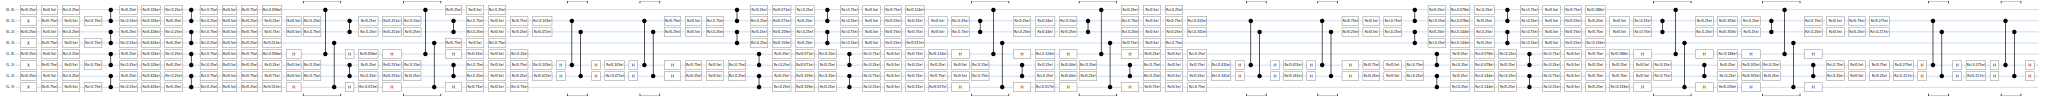

In [5]:
# Draw decomposed circuit (text + SVG)
print("--- Decomposed CZ + 1Q circuit ---")
print(decomposed_circuit)
print(f"\nCircuit Depth: {len(decomposed_circuit)} moments")
display(SVGCircuit(decomposed_circuit))